<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/YuluBizCase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Case- Yulu Hypothesis Testing**


**About Yulu-**

Yulu, India's pioneering micro-mobility service provider, has embarked on a mission to
revolutionize daily commutes by offering unique, sustainable transportation solutions.
However, recent revenue setbacks have prompted Yulu to seek the expertise of a consulting
company to delve into the factors influencing the demand for their shared electric cycles,
specifically in the Indian market.

**Column Profiling:**

    ● datetime: datetime
    ● season: season (1: spring, 2: summer, 3: fall, 4: winter)
    ● holiday : whether day is a holiday or not
    ● workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
    ● weather:
          o 1: Clear, Few clouds, partly cloudy
          o 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
          o 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
          o 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog
    ● temp: temperature in Celsius
    ● atemp: feeling temperature in Celsius
    ● humidity: humidity
    ● windspeed: wind speed
    ● casual: count of casual users
    ● registered: count of registered users
    ● count: count of total rental electric cycles including both casual and registered

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("/content/bike_sharing.csv")
print(df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [ ]:
# finding the shape of dataset
print(f"# rows: {df.shape[0]} \n# columns: {df.shape[1]}")

# rows: 10886 
# columns: 12


In [ ]:
# printing information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
# Converting to other datatypes
df['datetime'] = pd.to_datetime(df['datetime'])
cat_cols= ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
 df[col] = df[col].astype('object')

In [ ]:
# printing information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  object        
 2   holiday     10886 non-null  object        
 3   workingday  10886 non-null  object        
 4   weather     10886 non-null  object        
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 1020.7+ KB


In [ ]:
# printing the statistical summary
print(df.describe().T)

              count        mean         std   min      25%      50%       75%  \
season      10886.0    2.506614    1.116174  1.00   2.0000    3.000    4.0000   
holiday     10886.0    0.028569    0.166599  0.00   0.0000    0.000    0.0000   
workingday  10886.0    0.680875    0.466159  0.00   0.0000    1.000    1.0000   
weather     10886.0    1.418427    0.633839  1.00   1.0000    1.000    2.0000   
temp        10886.0   20.230860    7.791590  0.82  13.9400   20.500   26.2400   
atemp       10886.0   23.655084    8.474601  0.76  16.6650   24.240   31.0600   
humidity    10886.0   61.886460   19.245033  0.00  47.0000   62.000   77.0000   
windspeed   10886.0   12.799395    8.164537  0.00   7.0015   12.998   16.9979   
casual      10886.0   36.021955   49.960477  0.00   4.0000   17.000   49.0000   
registered  10886.0  155.552177  151.039033  0.00  36.0000  118.000  222.0000   
count       10886.0  191.574132  181.144454  1.00  42.0000  145.000  284.0000   

                 max  
seas

In [ ]:
# printing the statistical summary of object datatype
print(df.describe(include='object').T)

          count unique                  top freq
datetime  10886  10886  2011-01-01 00:00:00    1


In [ ]:
# checking for missing values
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [ ]:
# checking for duplicate records
df.duplicated().sum()

0

In [ ]:
# checking for skewness
df.skew(numeric_only = True)

temp          0.003691
atemp        -0.102560
humidity     -0.086335
windspeed     0.588767
casual        2.495748
registered    1.524805
count         1.242066
dtype: float64

**Insights-**

*   There are no missing values in the dataset.
*   casual, registered and count attributes might have outliers because their mean and median are very far away to one another and the value of standard deviation is also high which tells us that there is high variance in the data of these attributes.

**Skewness Analysis of Variables**

**Symmetrical Majority:**
The majority of the variables, including 'season' and 'temp', exhibit skewness values close to zero, suggesting relatively symmetrical distributions.

**Positive Skewness Insights:**
Variables such as 'holiday', 'weather', 'windspeed', 'casual', 'registered', and 'count' demonstrate positive skewness, pointing to a concentration of lower values and a rightward skew in their distributions.

**Negative Skewness Observations:**
In contrast, 'workingday', 'atemp', and 'humidity' exhibit negative skewness, implying a concentration of higher values and a leftward skew in their distributions.


In [ ]:
# minimum datetime and maximum datetime
print(df['datetime'].min(), df['datetime'].max())
# number of unique values in each categorical columns
print(df[cat_cols].melt().groupby(['variable', 'value'])[['value']].count())

2011-01-01 00:00:00 2012-12-19 23:00:00
                  value
variable   value       
holiday    0      10575
           1        311
season     1       2686
           2       2733
           3       2733
           4       2734
weather    1       7192
           2       2834
           3        859
           4          1
workingday 0       3474
           1       7412


**Analyzing the distribution of Numerical & Categorical variables**

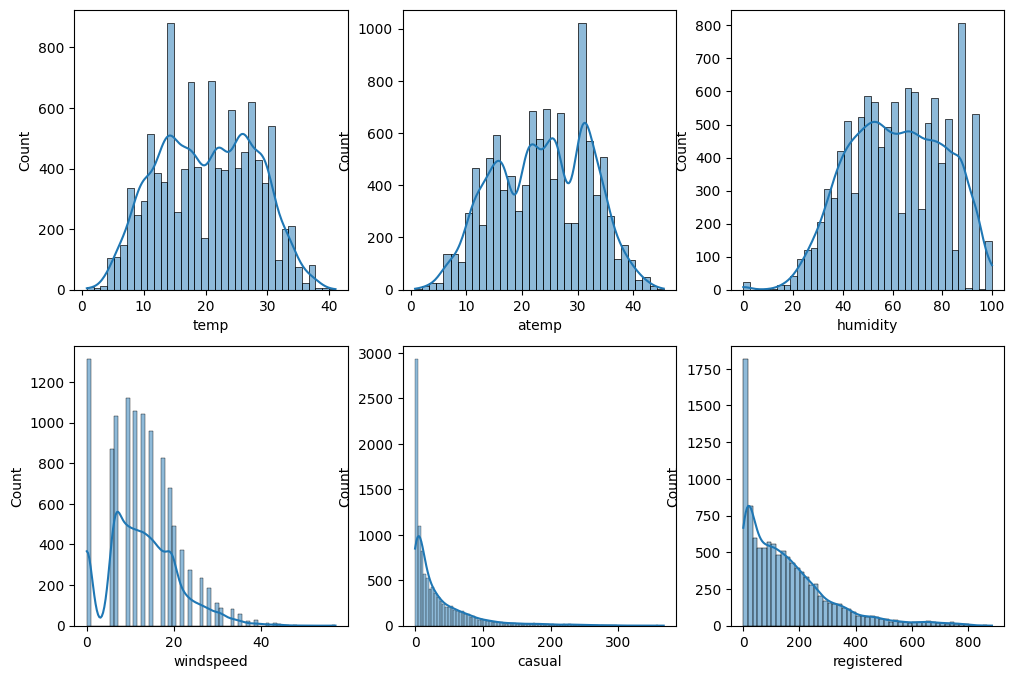

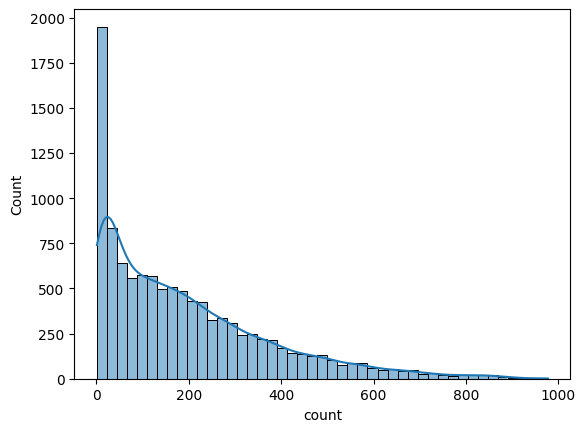

In [ ]:
# understanding the distribution for numerical variables
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual','registered','count']
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
index = 0
for row in range(2):
  for col in range(3):
    sns.histplot(df[num_cols[index]], ax=axis[row, col], kde=True)
    index += 1

plt.show()
sns.histplot(df[num_cols[-1]], kde=True)
plt.show()

**Insights-**

*   The attributes casual, registered and count somewhat looks like Log Normal
Distribution
*   The attributes temp, atemp and humidity looks like they follows the Normal Distribution
*  The attributes windspeed follows the binomial distribution

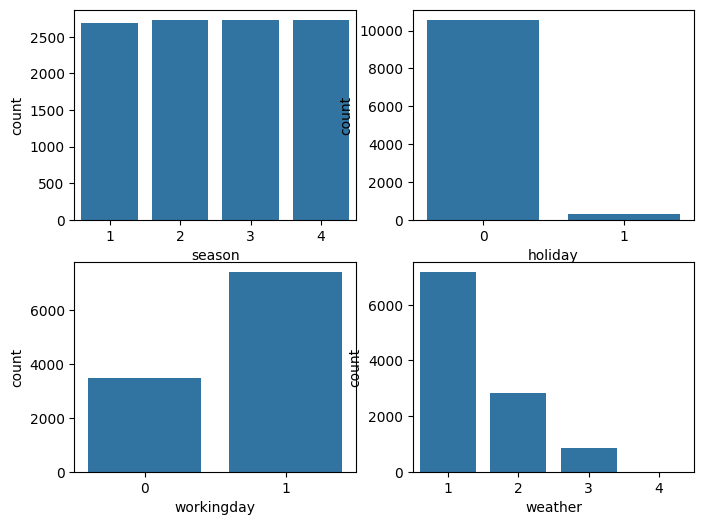

In [ ]:
# countplot of each categorical column
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))
index = 0
for row in range(2):
 for col in range(2):
  sns.countplot(data=df, x=cat_cols[index], ax=axis[row, col])
  index += 1

plt.show()

**Insights-**

The data is expected. Such as, each season has equal number of days.There are more working days. And the weather is majorly Clear, Few clouds, partly cloudy, partly cloudy.

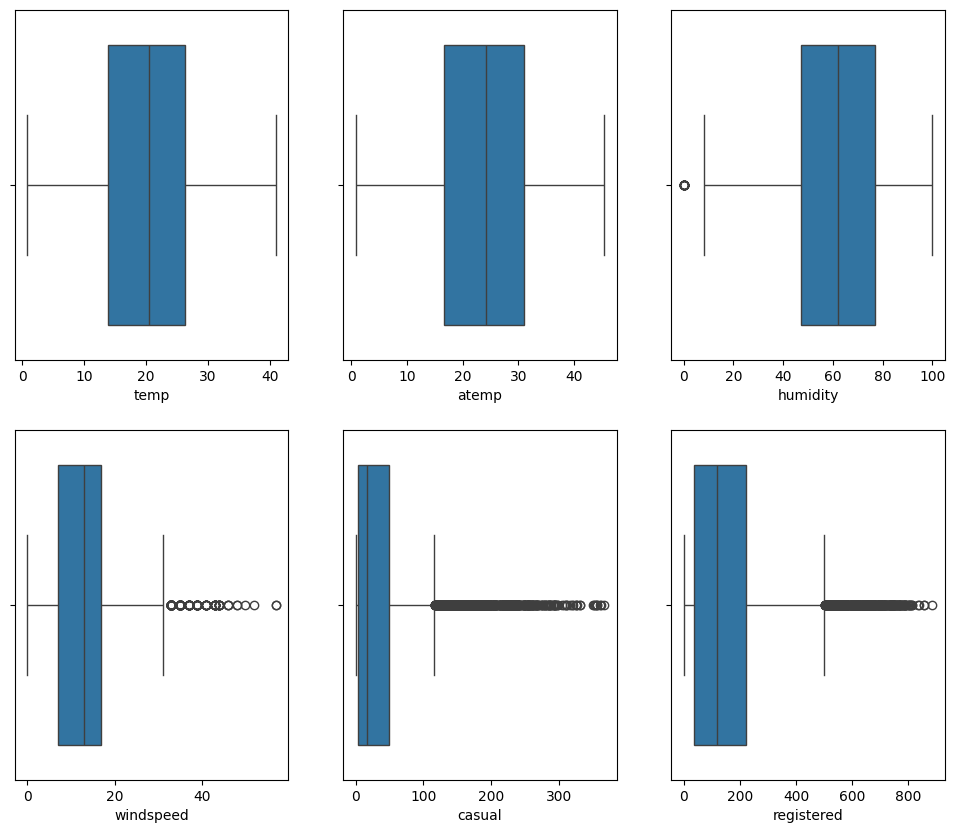

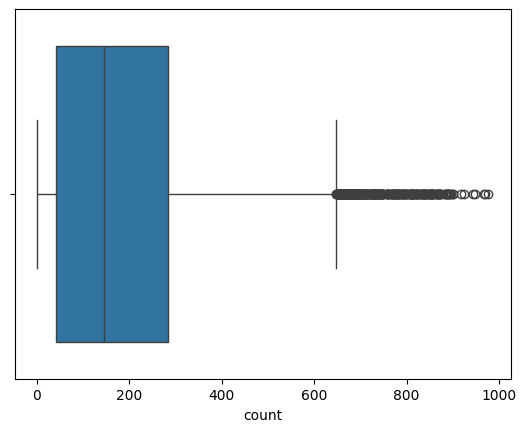

In [ ]:
# Checking for outliers in numerical columns
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12,10))

index = 0
for row in range(2):
    for col in range(3):
        sns.boxplot(x=df[num_cols[index]], ax=axis[row, col])
        index += 1

plt.show()
sns.boxplot(x=df[num_cols[-1]])
plt.show()

**Insights-**

The attributes like humidity, casual, registered and count have outliers in the dataset.

**Establishing a Relationship between the Dependent and Independent Variables.**

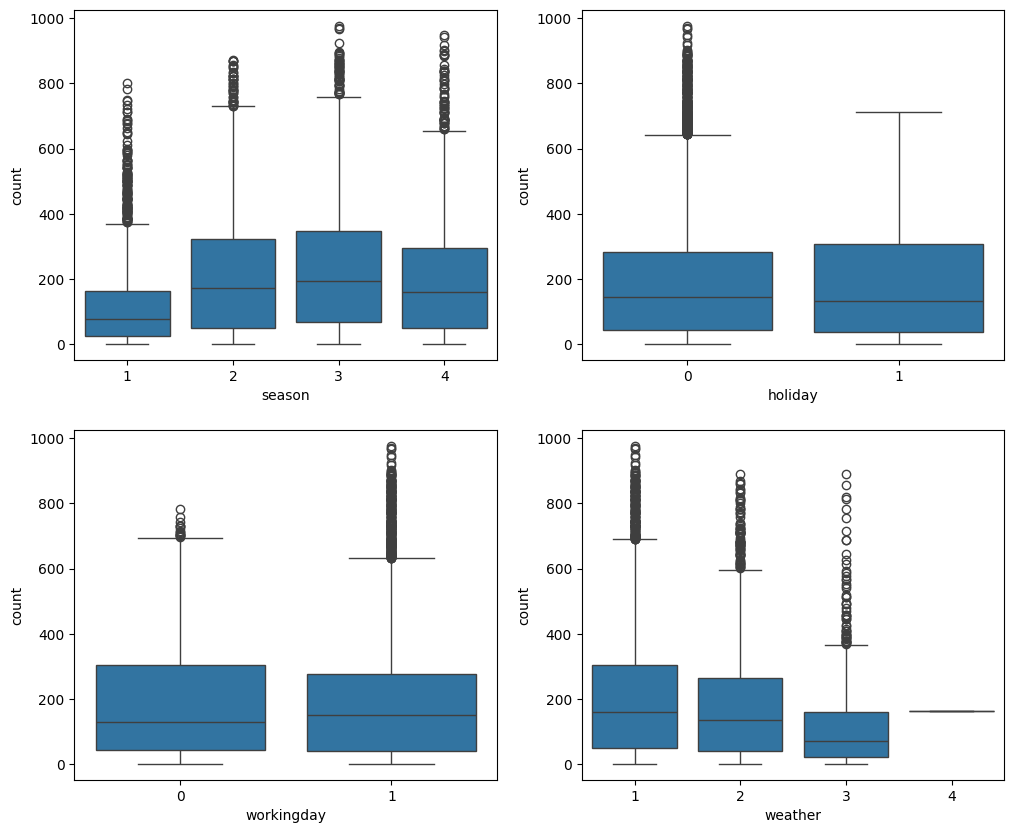

In [ ]:
# plotting categorical variables againt count using boxplots
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

index = 0
for row in range(2):
    for col in range(2):
        sns.boxplot(data=df, x=cat_cols[index], y='count', ax=axis[row, col])
        index += 1

plt.show()

**Insights-**
*   In summer and fall seasons more electric cycles are rented as compared to other
seasons.
*   Whenever its a holiday more electric cycles are rented.
*   It is also clear from the workingday also that whenever day is holiday or weekend, slightly more electric cycles were rented.
*   Whenever there is rain, thunderstorm, snow or fog, there were less electric cycles rented.

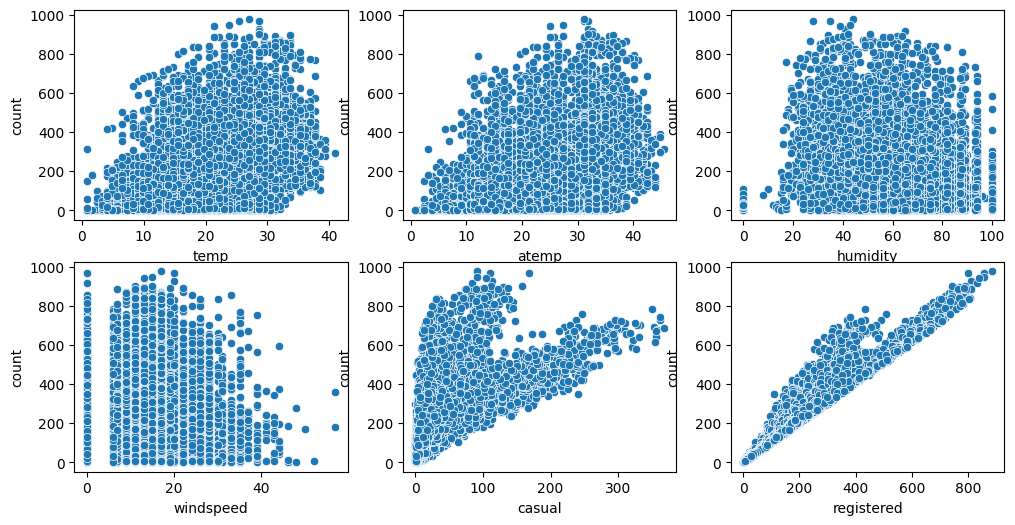

In [ ]:
# plotting numerical variables againt count using scatterplot
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
index = 0
for row in range(2):
 for col in range(3):
  sns.scatterplot(data=df, x=num_cols[index], y='count',
  ax=axis[row, col])
  index += 1

plt.show()


**Insights-**
*   Whenever the humidity is less than 20, number of electric cycles rented is very very low.
*   Whenever the temperature is less than 10, number of electric cycles rented is less.
*   Whenever the windspeed is greater than 35, number of electric cycles rented is less.






In [ ]:
# understanding the correlation between count and numerical variables
df.corr()['count']

datetime      0.310187
season        0.163439
holiday      -0.005393
workingday    0.011594
weather      -0.128655
temp          0.394454
atemp         0.389784
humidity     -0.317371
windspeed     0.101369
casual        0.690414
registered    0.970948
count         1.000000
Name: count, dtype: float64

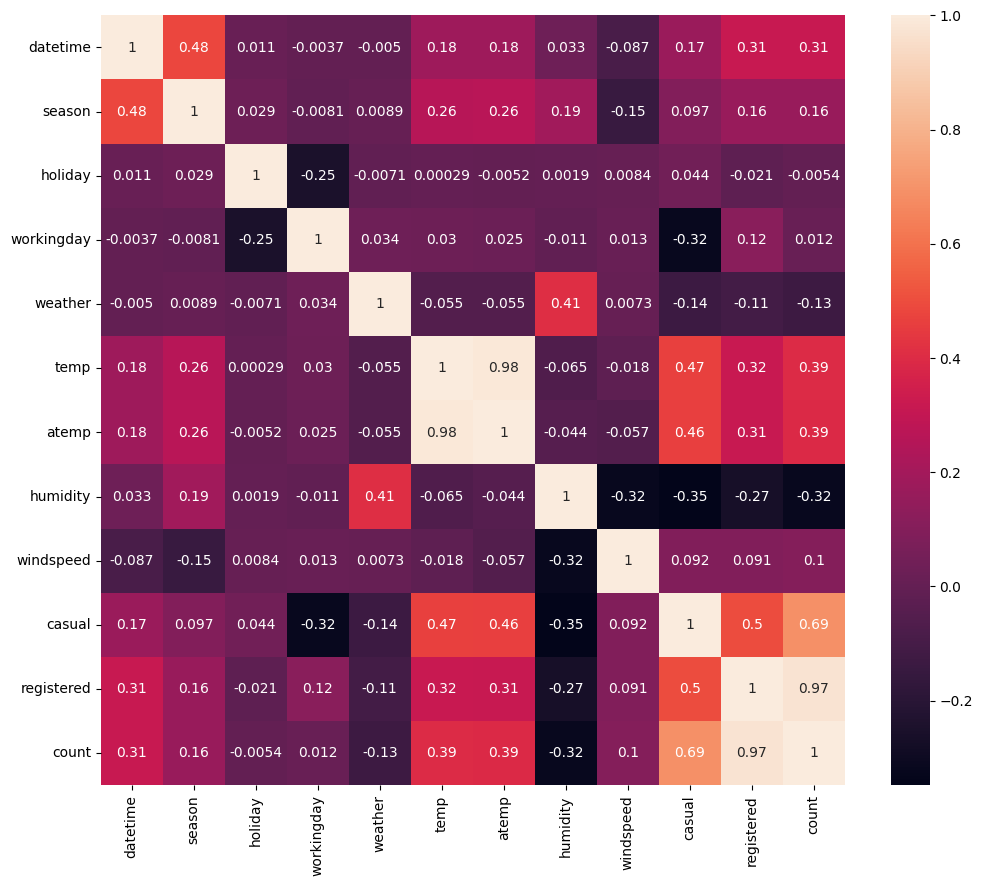

In [ ]:
# plotting heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

**Atemp:**
Strong positive correlation with 'temp' (0.98), indicating a close relationship.
Moderate positive correlation with 'casual' (0.46) and 'registered' (0.31).
Positive correlation with 'count' (0.39), suggesting a relationship with overall bike rentals.

**Temp (Temperature):**
Highly correlated with 'atemp' (0.98), indicating a strong connection.
Moderate positive correlation with 'casual' (0.47) and 'registered' (0.32).
Positive correlation with 'count' (0.39), showing a relationship with overall bike rentals.

**Humidity:**
Weak negative correlation with 'atemp' (-0.04) and 'temp' (-0.06).
Moderate negative correlation with 'casual' (-0.35), 'registered' (-0.27), and 'count' (-0.32). Indicates a tendency for fewer bike rentals during higher humidity.

**Windspeed:**
Weak negative correlation with 'atemp' (-0.06) and 'temp' (-0.02).
Weak positive correlation with 'casual' (0.09), 'registered' (0.09), and 'count' (0.10). Suggests a subtle influence on bike rentals with increasing wind speed.

**Casual (Casual Bike Rentals):**
Strong positive correlation with 'atemp' (0.46) and 'temp' (0.47).
Moderate negative correlation with 'humidity' (-0.35) and positive correlation with 'windspeed' (0.09). Highly correlated with 'registered' (0.50) and 'count' (0.69), indicating a significant impact on overall rentals.

**Registered (Registered Bike Rentals):**
Positive correlation with 'atemp' (0.31) and 'temp' (0.32).
Negative correlation with 'humidity' (-0.27) and positive correlation with 'windspeed' (0.09). Highly correlated with 'casual' (0.50) and 'count' (0.97), emphasizing a substantial impact on overall rentals.

**Count (Total Bike Rentals):**
Positive correlation with 'atemp' (0.39), 'temp' (0.39), and 'casual' (0.69).
Negative correlation with 'humidity' (-0.32).
Highly correlated with 'registered' (0.97), emphasizing the joint impact of casual and registered rentals on the overall count.

**Is there any significant difference between the number of bike rides on Weekdays and Weekends ?**

**Null Hypothesis:** Weekday has no effect on the number of cycles being rented.

**Alternate Hypothesis:** Weekend has effect on the number of cycles being rented.

**Significance level (alpha):** 0.05


Since we have two independent saples, we can go with Two Sample Independent T-Test.

**Assumptions of Two Sample Independent T-Test :**

The data should be normall distributed variances of the two groups are equal

Let the Confidence interval be 95%, so siginificance (alpha) is 0.05

To check if the data is normal, we will go with WilkinShapiroTest.

The test hypothesis for the Wilkin-Shapiro test are:

Ho: Data is normally distributed

Ha: Data is not normally distributed.

In [ ]:
np.random.seed(41)
df_subset = df.sample(100)["count"]
test_stat, p_val = stats.shapiro(df_subset)
p_val

2.6341072612012795e-07

Since the p_values is lesser than the significance level, Null hypothesis can be rejected.
Therefore, the Data is not normally distributed.


**QQ Plot analysis**

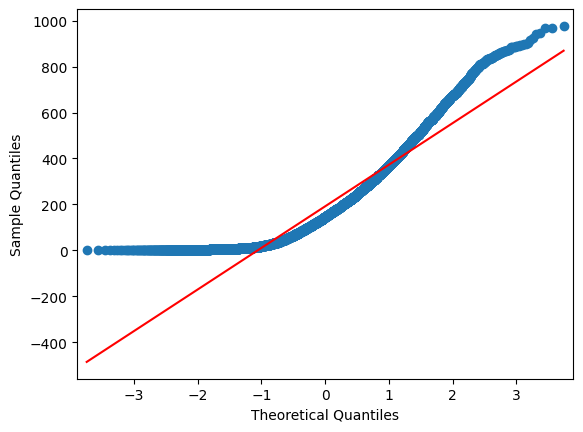

In [ ]:
# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(df['count'], line = 's')
plt.show()



To check if the variances of two groups are equal. We will perform Levene's test

The Test hypotheses for Levene's test are:

Ho: The variances are equal.

Ha: The variances are not equal.

In [ ]:
# change of holiday
df['holiday'] = df['holiday'].replace({0:'No',1:'Yes'})
# change of workingday
df['workingday'] = df['workingday'].replace({0:'No',1:'Yes'})

In [ ]:
weekday = df[df['workingday'] == 'Yes']['count']
weekend = df[df['workingday'] == 'No']['count']
levene_stat, p_val = stats.levene(weekday, weekend)
p_val

0.9437823280916695

<Axes: xlabel='count', ylabel='Density'>

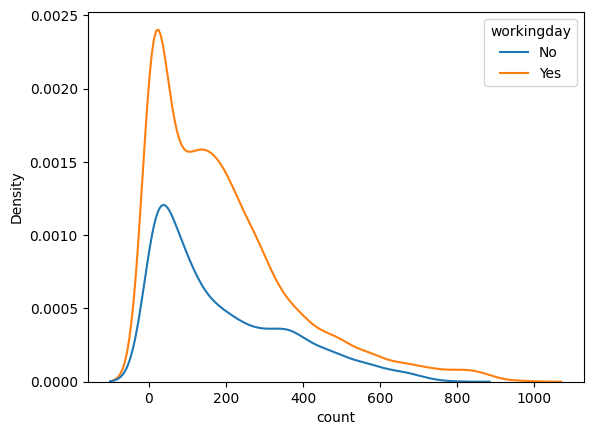

In [ ]:
sns.kdeplot(data = df, x = 'count', hue = 'workingday')

<Axes: xlabel='count', ylabel='Count'>

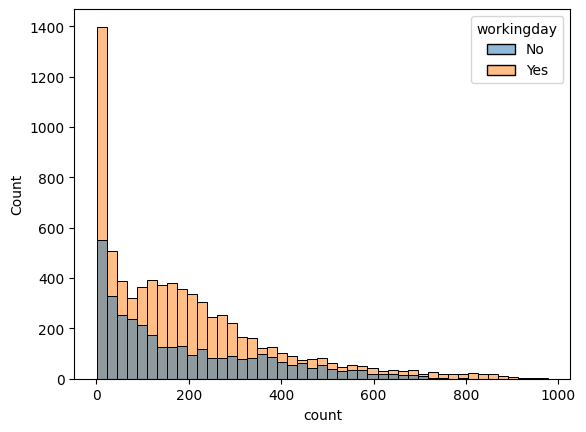

In [ ]:
sns.histplot(data = df, x = 'count', hue = 'workingday')

Hence the p_values is greater than the significance level, Null hypothesis can be accepted.

Therefore, the variances are approximately equal.

Despite the data is not normally distributed according to both the Wilkin-ShapiroTest and qqplot.

It is important to highlight that the variances between the two groups are equal.

So we can proceed with the Two Sample Independent T-Test.

**The hypothesis for the t-test are:**

Ho: There is no significant difference between working and non-working days.

Ha: There is a significant difference between working and non-working days.

In [ ]:
working_day = df[df['workingday'] == 'Yes']['count']
holiday = df[df['workingday'] == 'No']['count']
levene_stat, p_val = stats.levene(working_day, holiday)
print(p_val)

0.9437823280916695


In [ ]:
ttest_stat, p_val = stats.ttest_ind(working_day, holiday)
p_val

0.22644804226361348

**Insights-**

Since pvalue is greater than 0.05 so we can not reject the Null hypothesis. We don't have the sufficient evidence to say that weekday has effect on the number of cycles being rented.

**Is the demand of bicycles on rent is the same for different Weather
conditions?**

Since we have more than two categories now, so will use ANOVA here.
Assumptions for ANOVA are:

1. The population data should be normally distributed- The data is not normal as verified by Wilkin-Shapiro test and the qqplot.
2. The data points must be independent- This condition is satisfied.
3. Approximately equal variance within groups- This will be verified using Levene's test.



In [ ]:
# skewness of weather
df.groupby('weather')['count'].skew()


weather
1    1.139857
2    1.294444
3    2.187137
4         NaN
Name: count, dtype: float64

In [ ]:
# kurtosis test of weather
df.groupby('weather')['count'].apply(lambda x: x.kurtosis())

weather
1    0.964720
2    1.588430
3    6.003054
4         NaN
Name: count, dtype: float64

<Axes: xlabel='count', ylabel='Density'>

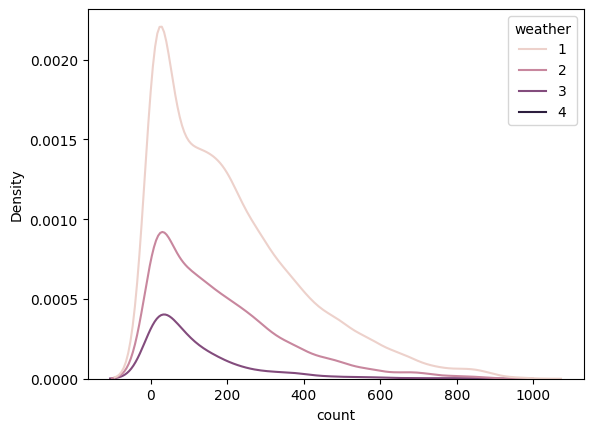

In [ ]:
sns.kdeplot(data = df, x = 'count', hue = 'weather')

<Axes: xlabel='count', ylabel='Count'>

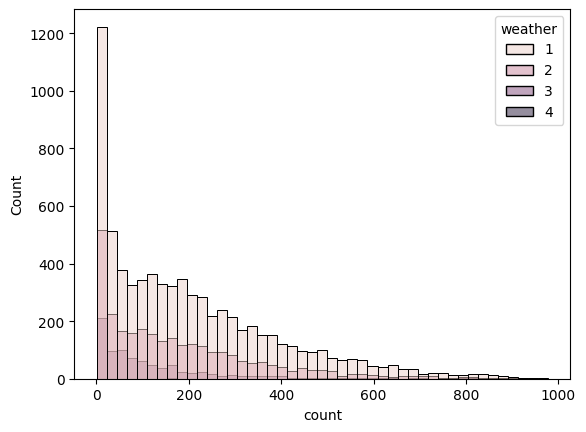

In [ ]:
sns.histplot(data = df, x = 'count', hue = 'weather')

The Test hypothesis for Levene's test are:

Ho: The variances are equal.

Ha: The variances are not equal.

In [ ]:
weather1 = df[df['weather'] == 1]['count']
weather2 = df[df['weather'] == 2]['count']
weather3 = df[df['weather'] == 3]['count']
weather4 = df[df['weather'] == 4]['count']
levene_stat, p_val = stats.levene(weather1, weather2, weather3,weather4)
p_val

3.504937946833238e-35

Hence the p_values is smaller than the significance level, Null hypothesis can be rejected.

Therefore, the variances are not equal.

Two of the three conditions of ANOVA are not met, We will still perform ANOVA.
Then We will also perform Kruskal's test and compare the results.

In case of any discrepancies, Kruskal's test results will be considered, since data does not met conditions of ANOVA.


The hypothesis for ANOVA are:

Ho: There is no significant difference between demand of bicycles for different
Weather conditions.

Ha: There is a significant difference between demand of bicycles for different
Weather conditions.

In [ ]:

gp1 = df[df['weather']==1]['count'].values
gp2 = df[df['weather']==2]['count'].values
gp3 = df[df['weather']==3]['count'].values
gp4 = df[df['weather']==4]['count'].values

In [ ]:
# conduct the one-way anova
stats.f_oneway(gp1, gp2, gp3, gp4)

F_onewayResult(statistic=65.53024112793271, pvalue=5.482069475935669e-42)

Since p-value is less than 0.05, we reject the null hypothesis. This implies weather has effect on the number of electric cycles rented.

**Kruskal Test on weather**

In [ ]:
kruskal_stat, p_val = stats.kruskal(weather1, weather2, weather3,weather4)
p_val

3.501611300708679e-44

Again the p_values is smaller than the significance level, Null hypothesis can be rejected.
Therefore, we can conclude that there is a significant difference between demand of bicycles for different Weather conditions.


**Is the demand of bicycles on rent is the same for different Seasons?**

Here also we have more than two categories now, so will use ANOVA here.
Assumptions for ANOVA are:

1. The population data should be normally distributed- The data is not normal as verified by Wilkin-Shapiro test and the qqplot.
2. The data points must be independent- This condition is satisfied.

In [ ]:
# skewness of seasons
df.groupby('season')['count'].skew()

season
1    1.888056
2    1.003264
3    0.991495
4    1.172117
Name: count, dtype: float64

In [ ]:
# kurtosis test of seasons
df.groupby('weather')['count'].apply(lambda x: x.kurtosis())

weather
1    0.964720
2    1.588430
3    6.003054
4         NaN
Name: count, dtype: float64

<Axes: xlabel='count', ylabel='Density'>

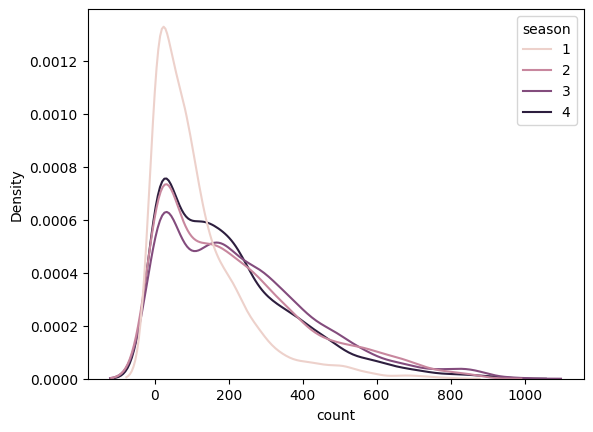

In [ ]:
sns.kdeplot(data = df, x = 'count', hue = 'season')

<Axes: xlabel='count', ylabel='Count'>

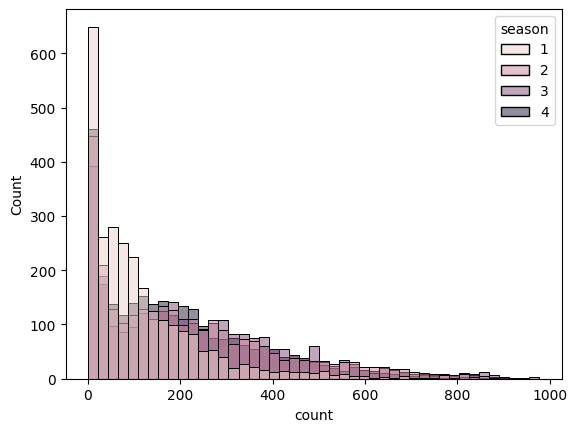

In [ ]:
sns.histplot(data = df, x = 'count', hue = 'season')

The Test hypothesis for Levene's test are:

Ho: The variances are equal.

Ha: The variances are not equal.


In [ ]:
spring = df[df['season'] == 1]['count']
summer = df[df['season'] == 2]['count']
fall = df[df['season'] == 3]['count']
winter = df[df['season'] == 4]['count']
levene_stat, p_val = stats.levene(spring,summer,fall,winter)
p_val

1.0147116860043298e-118

Hence the p_values is smaller than the significance level, Null hypothesis can be rejected.
Therefore, the variances are not equal.
As like before, we still use both ANOVA and Kruskal's test, comparing the results.
If discrepancies arise, we'll rely on Kruskal's test, Since data does not meet the conditions for ANOVA.

The hypothesis for ANOVA are:

Ho: There is no significant difference between demand of bicycles for different
Seasons.

Ha: There is a significant difference between demand of bicycles for different
Seasons.


In [ ]:
anova_stat, p_val = stats.f_oneway(spring ,summer, fall, winter)
p_val


6.164843386499654e-149

Hence the p_values is smaller than the significance level, Null hypothesis can be rejected.

Therefore, There is a significant difference between demand of bicycles for different Seasons.

**Kruskal Test on season**

In [ ]:
kruskal_stat, p_val = stats.kruskal(spring ,summer, fall, winter)
p_val

2.479008372608633e-151

Again the p_values is smaller than the significance level, Null hypothesis can be rejected.
Therefore, we can conclude that there is a significant difference between demand of bicycles for different Seasons.

Analysis of Weather Conditions Across Seasons using Chi-square Test

The hypothesis for the chi-square test are:

Ho: Season and Weather are independent of each other.

Ha: Season and Weather are dependent on each other.


In [ ]:
contingency_table = pd.crosstab(df['weather'], df['season'])
print(contingency_table)

season      1     2     3     4
weather                        
1        1759  1801  1930  1702
2         715   708   604   807
3         211   224   199   225
4           1     0     0     0


In [ ]:
stats.chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=49.15865559689363, pvalue=1.5499250736864862e-07, dof=9, expected_freq=array([[1.77454639e+03, 1.80559765e+03, 1.80559765e+03, 1.80625831e+03],
       [6.99258130e+02, 7.11493845e+02, 7.11493845e+02, 7.11754180e+02],
       [2.11948742e+02, 2.15657450e+02, 2.15657450e+02, 2.15736359e+02],
       [2.46738931e-01, 2.51056403e-01, 2.51056403e-01, 2.51148264e-01]]))

Hence the p_values(1.5499250736864862e-07) is smaller than the significance level, Null hypothesis can be rejected.

Therefore, we can conclude that Season and Weather are dependent on each other.

 **Strategic Recommendations for Yulu's Profitable Growth**

 **Optimize Bike Distribution in Peak Months:**

Concentrate bike deployment efforts during peak months, especially in June, July, and August, to meet increased demand and capitalize on favorable weather conditions.

**Seasonal Marketing Strategies:**

Tailor marketing efforts to leverage the seasonal trend, promoting Yulu's services more aggressively during summer months to attract a larger user base.

**Enhance User Engagement in Off-Peak Months:**

Implement targeted promotional campaigns or discounts during off-peak months (e.g.,January to March) to encourage increased bike rentals and maintain consistent revenue flow.

**Weather-Responsive Pricing:**

Consider implementing dynamic pricing strategies that respond to weather conditions.
For example, adjusting rental rates during extreme weather days to optimize revenue.

**Diversify Revenue Streams:**

Explore additional revenue streams, such as partnerships, sponsorships, or offering premium membership services with added benefits, to diversify income sources and boost overall profitability.

**Enhance User Experience:**

Invest in technology and infrastructure to improve the overall user experience, including app features, bike maintenance, and customer support, fostering loyalty and repeat business.

**Optimize Bike Deployment on Working Days:**

Given the lack of significant differences in bike rentals between working and nonworking days, consider adjusting bike deployment strategies to ensure optimal resource allocation throughout the week.

**Adapt to Different Weather Conditions:**

Change promotions or discounts based on the weather. If it's rainy, for example, offer special deals to encourage more people to use the bikes.

**Promote Bikes Differently in Each Season:**

Advertise the bikes differently in each season. For example, highlight summer
promotions in June, July, and August when more people want to ride bikes.

**Combine Season and Weather Plans:**

Plan bike availability based on both the season and the weather to make sure people have the bikes they need when they want them. For example, have more bikes available on sunny days in the summer.